# Load Libraries

Run on conda env `findr`

In [27]:
# import pyNeuroDAP as ndap

ModuleNotFoundError: No module named 'autograd'

In [2]:
import functools

from absl import app
from absl import flags
from absl import logging

from absl import app
from absl import flags
from absl import logging

import jax
from ml_collections import config_flags

FLAGS = flags.FLAGS

import jax
import numpy as np
from typing import Any, Callable, Dict, Tuple, Sequence
from jax.nn import softplus
from jax import lax, random, numpy as jnp
from jax.scipy.special import gammaln
from flax.core import freeze, unfreeze
from flax import linen as nn
from flax import serialization
from flax.training import train_state, checkpoints
from flax import struct
import optax
import orbax.checkpoint
import ml_collections
from ml_collections import config_dict
from scipy.stats import norm, bootstrap

# Bring your packages onto the path
import sys, os
sys.path.append(os.path.abspath('/Users/shunli/Projects/pyNeuroDAP/findr')) # add findr path

import models
import train
import mycells
import utils

import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import matplotlib.colors as colors

from sklearn.decomposition import PCA
from scipy.ndimage.filters import gaussian_filter
import csv

/var/folders/zd/cj43fhkd6pddg_t4m2l4bhth0000gn/T/ipykernel_57422/3542117752.py:47: DeprecationWarning: Please import `gaussian_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import gaussian_filter


# Define colors

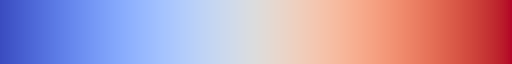

In [10]:
scw = []

with open('/Users/shunli/Projects/pyNeuroDAP/findr/notebooks/smooth-cool-warm-table-float-1024.csv', mode='r') as infile:
    reader = csv.reader(infile)
    for i, rows in enumerate(reader):
        if i > 0:
            r = [float(i) for i in rows]
            scw.append(tuple(r[1:]))
            scw.append(r[0])
            
def make_colormap(seq):
    """Return a LinearSegmentedColormap
    seq: a sequence of floats and RGB-tuples. The floats should be increasing
    and in the interval (0,1).
    """
    seq = list(seq) + [(None,) * 3]
    cdict = {'red': [], 'green': [], 'blue': []}
    for i, item in enumerate(seq):
        if isinstance(item, float):
            r1, g1, b1 = seq[i - 1]
            r2, g2, b2 = seq[i + 1]
            cdict['red'].append([item, r1, r2])
            cdict['green'].append([item, g1, g2])
            cdict['blue'].append([item, b1, b2])
    return colors.LinearSegmentedColormap('CustomMap', cdict)

c = colors.ColorConverter().to_rgb
rvb = make_colormap(scw)
cmap = rvb
rvb

In [6]:
blue = [0.229999504, 0.298998934, 0.754000139]
red = [0.706000136, 0.015991824, 0.150000072]
purple = [0.4588, 0.4392, 0.7020]
mint = [0.1059, 0.6196, 0.4667]

# Load FINDR network

In [22]:
# Shijia's data
ckptdir = '/Users/shunli/Projects/pyNeuroDAP/Data/20250622-Data-InsCtx/findr-results-20251107'
datapath = '/Users/shunli/Projects/pyNeuroDAP/Data/20250622-Data-InsCtx/20250618_M346_4W50_g0_ccm_findr_dataset.npz'

# Paolo's data
ckptdir = '/Users/shunli/Projects/pyNeuroDAP/Data/Rec_Upstream_DCN_1_250411_MixedmW_500ms_041225001/250411-Paolo-DCN/findr-results-20251109'
datapath = '/Users/shunli/Projects/pyNeuroDAP/Data/Rec_Upstream_DCN_1_250411_MixedmW_500ms_041225001/250411-Paolo-DCN/findr_dataset.npz'

In [23]:
fold=1 # which fold (1, 2, 3, 4, 5) to look at?
train_ds, val_ds, test_ds, ds, perms = train.get_datasets(datapath, ckptdir, k_cv=fold, baseline_fit=True)

# Print ds component shape
print(ds.keys())
print(f"externalinputs: {ds['externalinputs'].shape}")
print(f"spikes: {ds['spikes'].shape}")
print(f"baselineinputs: {ds['baselineinputs'].shape}")
print(f"lengths: {ds['lengths'].shape}")


dict_keys(['spikes', 'externalinputs', 'lengths', 'baselineinputs'])
externalinputs: (525, 120, 3)
spikes: (525, 120, 142)
baselineinputs: (525, 120, 142)
lengths: (525,)


In [24]:
import orbax.checkpoint as ocp
num_epochs = 3000
manager = ocp.CheckpointManager(ckptdir, ocp.StandardCheckpointer())
structure = manager.item_metadata(num_epochs)
target = jax.tree_util.tree_map(lambda x: np.zeros(x.shape), structure)

restored_state = checkpoints.restore_checkpoint(
    ckpt_dir=ckptdir+'/'+str(num_epochs)+'/default',
    target=target, 
    parallel=False
)

config = jax.tree_util.tree_map(lambda x: x.flatten()[0].item(), restored_state['config'])
config['features_posterior'] = [config['features_posterior']['0']]
config['features_prior'] = [config['features_prior']['0']]
config=config_dict.ConfigDict(config)

train_ds_size = len(train_ds['externalinputs'])
steps_per_epoch = train_ds_size // config.batch_size
learning_rate_fn = train.create_learning_rate_fn(config, steps_per_epoch)

In [25]:
# load parameters for generating spikes

# Create and split JAX RNG keys for reproducible sampling/initialization.
rng = random.PRNGKey(0)
rng, key_1, key_2, key_3 = random.split(rng, 4)

# Pull the trained prior (dynamics) parameters from your checkpoint and package them under the name that the model expects (GNSDECell_0). 
# These are the learned weights of the drift network
gnsdeparams = freeze({'GNSDECell_0': unfreeze(restored_state['model']['params']['prior_process'])})

# Number of trials in the dataset
batch_size = len(ds['lengths'])

# Instantiate the generative dynamics module (GNSDE)
# features describes the MLP architecture used for the drift
# alpha sets the time-scale inside the integrator
gnsde = models.GNSDE(
    features=config.features_prior,
    alpha=config.alpha
)

# Initialize the recurrent latent state (carry) for all trials, with the task-related latent dimensionality.
carry_dl = gnsde.initialize_carry(
  key_2,
  batch_size, 
  config.task_related_latent_size
)

# Grab the learned posterior diffusion scale (per-latent) and sample Gaussian noise with that scale. 
# This is used to generate noisy trajectories below.
logvar = restored_state['model']['params']['posterior_process']['PosteriorSDECell_0']['logvar']
noise = random.normal(
    key_3, 
    shape=ds['externalinputs'].shape[:-1] + (config.task_related_latent_size,)
) * nn.sigmoid(logvar)

# Set up linear readouts (not used later in this cell). 
# In the trained model, these map latents → neurons.
task_related_latents_to_neurons = nn.Dense(
  ds['spikes'].shape[-1]
)

non_task_related_latents_to_neurons = nn.Dense(
    ds['spikes'].shape[-1]
)

# Run the generative prior forward with noise to produce noisy latent trajectories latents for every trial/time, conditioned on externalinputs
_, (latents, mu_theta, mu) = gnsde.apply(
    {'params': gnsdeparams},
    carry_dl,
    ds['externalinputs'],
    noise
)

# Run the same dynamics without noise to get latents_noiseless. 
# This “clean” version is used to define the plotting plane.
_, (latents_noiseless, mu_theta, mu) = gnsde.apply(
    {'params': gnsdeparams},
    carry_dl,
    ds['externalinputs'],
    0*noise
)

# Build the drift network as a standalone module for evaluating the flow field later
f = mycells.Flow(
  features=config.features_prior
)

# Convert the model’s internal step to plotting units.
tau = 0.01 / config.alpha
# Same trained dynamics weights, now in the format f.apply(...) expects.
flowparams = freeze({'params': unfreeze(restored_state['model']['params']['prior_process'])})

# Take the trained task-latent → neuron weight matrix C_ and SVD it 
# to grab a convenient 2-D basis (C) spanning the task-latent subspace.
C_ = restored_state['model']['params']['task_related_latents_to_neurons']['kernel']
u, s, vh = np.linalg.svd(C_.T, full_matrices=False)
C = np.diag(s) @ vh

# Project noiseless latents into the SVD basis 
zz = latents_noiseless @ C.T
# PCA the first 100 ms across trials to get a stable 2-D visualization plane
pca = PCA(n_components=2)
pca.fit(np.reshape(zz[:,:100,:], (-1, 2)))
# Transform all time points into that plane (z_pc).
z_pc = pca.transform(np.reshape(zz, (-1, 2)))
z_pc = np.reshape(z_pc, zz.shape)

# Fit an affine map from latent space → 2-D PC plane, using early time points
# p = zCT_pca + b_pca
# Then apply it to the noisy latents z_pc_ (for trajectory overlays later). 
# You also keep the inverse C_pca_inv for going plane → latent.
latents_ = np.reshape(latents_noiseless[:,:100,:], (-1, 2))
latents_ = np.insert(latents_, 0, 1.0, axis=1)
CT_pca_b = np.linalg.pinv(latents_.T @ latents_) @ latents_.T @ np.reshape(z_pc[:,:100,:], (-1, 2))
CT_pca = CT_pca_b[1:, :]
C_pca_inv = np.linalg.pinv(CT_pca.T)
b_pca = CT_pca_b[0, :]
z_pc_ = latents @ CT_pca + b_pca # just doing translation and rotation to the SVD'ed latents


# Align latent trajectoris

In [28]:
def get_traces(data, event, pre_steps, post_steps):
    data = np.asarray(data)
    T    = data.shape[0]

    if len(data) == len(event):
        event_idx = np.where(np.diff(event) == 1)[0] + 1
    else:
        event_idx = np.asarray(event, dtype=int)

    n_trials   = len(event_idx)
    window_len = pre_steps + post_steps + 1

    aligned_data = np.zeros((n_trials, window_len), dtype=data.dtype)

    for i, idx in enumerate(event_idx):
        start = idx - pre_steps
        end   = idx + post_steps
        lo = max(start, 0)
        hi = min(end, T - 1)
        w_lo = lo - start
        w_hi = w_lo + (hi - lo) + 1
        aligned_data[i, w_lo : w_hi] = data[lo : hi + 1]

    return aligned_data

## Paolo

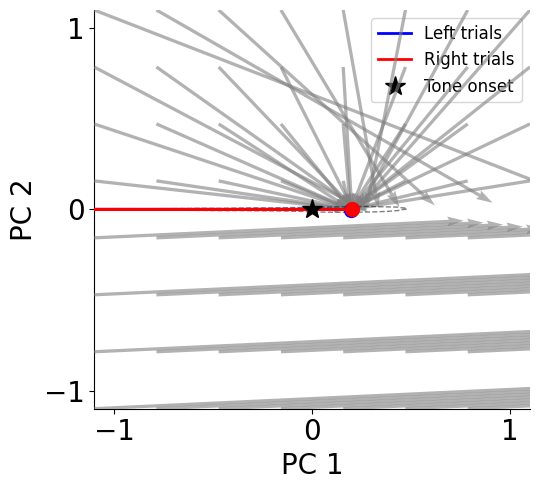

Left trials: 260, Right trials: 265
Tone onset alignment: 50 steps before, 200 steps after


In [37]:
# -------- 1) Find tone onset time per trial and label left vs right --------
U = ds['externalinputs']          # (N_trials, T, 3)

tone_left_onset = (U[:, :, 0] > 0)
tone_right_onset = (U[:, :, 1] > 0)
laser_onset = (U[:, :, 2] > 0)

# Find first tone onset time for each trial
tone_left_times = np.array([np.flatnonzero(tone_left_onset[i])[0] if np.any(tone_left_onset[i]) else -1 
                             for i in range(U.shape[0])])
tone_right_times = np.array([np.flatnonzero(tone_right_onset[i])[0] if np.any(tone_right_onset[i]) else -1 
                              for i in range(U.shape[0])])

# Label trials: left if left tone comes first, right if right tone comes first
# Keep trials where exactly one tone is present
is_left_trial = (tone_left_times >= 0) & (tone_right_times < 0)
is_right_trial = (tone_right_times >= 0) & (tone_left_times < 0)
valid_trials = is_left_trial | is_right_trial

# Get tone onset times for valid trials
tone_onset_times = np.where(is_left_trial, tone_left_times, 
                           np.where(is_right_trial, tone_right_times, -1))

# -------- 2) Align trajectories to tone onset --------
pre_steps, post_steps = 50, 200   # e.g., 0.5 s pre, 2.0 s post at 10 ms bins
win_len = pre_steps + post_steps + 1

aligned = []      # (n_kept, win_len, 2)
labels  = []      # (n_kept,) - True for left, False for right
kept_ix  = []

for i in np.where(valid_trials)[0]:
    tone_onset = [int(tone_onset_times[i])]
    x_al = get_traces(z_pc_[i, :, 0], tone_onset, pre_steps, post_steps)[0]  # aligned PC1: x-axis
    y_al = get_traces(z_pc_[i, :, 1], tone_onset, pre_steps, post_steps)[0]  # aligned PC2: y-axis
    aligned.append(np.stack([x_al, y_al], axis=-1))   # (win_len, 2)
    labels.append(is_left_trial[i])  # True for left, False for right
    kept_ix.append(i)

aligned = np.stack(aligned, axis=0)   # (n_kept, win_len, 2)
labels  = np.asarray(labels, dtype=bool)
t_rel   = np.arange(-pre_steps, post_steps + 1)  # 0 = tone onset

# -------- 3) Condition-specific average trajectories --------
avg_traj_left   = aligned[labels].mean(axis=0)   if labels.any()   else np.full((win_len, 2), np.nan)
avg_traj_right  = aligned[~labels].mean(axis=0)  if (~labels).any() else np.full((win_len, 2), np.nan)
avg_trajectories = [avg_traj_left, avg_traj_right]

# Separation curve (Euclidean distance between condition means over time)
sep_curve = np.linalg.norm(avg_traj_left - avg_traj_right, axis=1)  # length = win_len

# -------- 4) Flow fields for each condition --------
xrange = (np.abs(np.quantile(z_pc_[:, :, 0].flatten(), 0.01)) +
          np.abs(np.quantile(z_pc_[:, :, 0].flatten(), 0.99))) / 2
resolution = 8
x, y = np.meshgrid(
    np.linspace(-1.1*xrange, 1.1*xrange, num=resolution),
    np.linspace(-1.1*xrange, 1.1*xrange, num=resolution)
)

def compute_flow_field(input_vec):
    u = np.zeros_like(x)
    v = np.zeros_like(y)
    energy = np.zeros_like(x)
    for i in range(resolution):
        for j in range(resolution):
            p = np.array([x[i, j], y[i, j]])
            z = C_pca_inv @ (p - b_pca)                            # PC -> latent
            dz = f.apply(flowparams, z, input_vec)                 # drift in latent
            uv = CT_pca.T @ dz / tau                               # latent -> PC, rescaled
            energy[i, j] = np.linalg.norm(uv[:2] / xrange)
            u[i, j], v[i, j] = uv[0], uv[1]
    return u, v, energy

# Representative input at tone onset for each condition:
def rep_input_at_tone_onset(mask):
    if not np.any(mask): 
        return np.zeros(U.shape[-1])
    ev_rows = [U[i, tone_onset_times[i], :] for i in np.where(valid_trials & mask)[0]]
    return np.mean(np.stack(ev_rows, axis=0), axis=0)

u_rep_left   = rep_input_at_tone_onset(labels)
u_rep_right  = rep_input_at_tone_onset(~labels)

u_L, v_L, energy_L   = compute_flow_field(u_rep_left)
u_R, v_R, energy_R   = compute_flow_field(u_rep_right)

# Use left flow field (can change to right if preferred)
u_field, v_field, energy_field = u_L, v_L, energy_L

# -------- 5) Flip sign (purely cosmetic; use one condition as reference) --------
def sign_of_max_abs(x):  # like max(..., key=abs) but returns the signed value
    i = np.argmax(np.abs(x))
    return x[i]

time = min(100, win_len)   # keep your original 'time' logic but bounded by window
ref = avg_traj_left if np.isfinite(avg_traj_left).any() else avg_traj_right

flip_horizontally = -1 if sign_of_max_abs(ref[:time, 0]) > 0 else 1
flip_vertically   = -1 if sign_of_max_abs(ref[:time, 1]) > 0 else 1

# -------- 6) Plot flow field with left and right trajectories --------
fig, ax = plt.subplots(figsize=(5.5, 5))

# Plot vector field
ax.quiver(
    flip_horizontally * x/xrange, 
    flip_vertically * y/xrange, 
    flip_horizontally * u_field/xrange, 
    flip_vertically * v_field/xrange, 
    angles='xy', 
    color='gray', 
    alpha=0.6,
    scale_units='xy', 
    scale=10, 
    zorder=150
)

# Plot trial-averaged trajectories
if np.isfinite(avg_traj_left).any():
    ax.plot(
        flip_horizontally * avg_traj_left[:time, 0]/xrange, 
        flip_vertically * avg_traj_left[:time, 1]/xrange, 
        '-', color='blue', linewidth=2, label='Left trials', zorder=1100
    )
    ax.plot(
        [flip_horizontally * avg_traj_left[time, 0]/xrange], 
        [flip_vertically * avg_traj_left[time, 1]/xrange], 
        'o', markersize=10, color='blue', zorder=1100
    )

if np.isfinite(avg_traj_right).any():
    ax.plot(
        flip_horizontally * avg_traj_right[:time, 0]/xrange, 
        flip_vertically * avg_traj_right[:time, 1]/xrange, 
        '-', color='red', linewidth=2, label='Right trials', zorder=1100
    )
    ax.plot(
        [flip_horizontally * avg_traj_right[time, 0]/xrange], 
        [flip_vertically * avg_traj_right[time, 1]/xrange], 
        'o', markersize=10, color='red', zorder=1100
    )

# Plot sample zone (density of all trajectories)
z_pc__ = np.reshape(z_pc_[:,:time,:], (-1, 2))
counts, xbins, ybins = np.histogram2d(
    flip_horizontally * z_pc__[:,0] / xrange, 
    flip_vertically * z_pc__[:,1] / xrange,
    bins=30
)
cs = ax.contour(
    counts.transpose(),
    extent=[xbins[0],xbins[-1],ybins[0],ybins[-1]],
    linewidths=1, 
    linestyles="dashed", 
    cmap='gray', 
    levels=[50,10000], 
    zorder=1000,
    alpha=0.5
)

# Mark tone onset (time = 0)
ax.plot([0], [0], 'k*', markersize=15, label='Tone onset', zorder=1200)

# Axes labels
ax.set_ylabel("PC 2", fontsize=20)
ax.set_xlabel("PC 1", fontsize=20)
ax.set_xticks([-1, 0, 1])
ax.set_yticks([-1, 0, 1])
ax.set_xlim([-1.1, 1.1])
ax.set_ylim([-1.1, 1.1])
ax.tick_params(axis='both', which='major', labelsize=20)
ax.legend(loc='best', fontsize=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.tight_layout()
plt.show()

print(f"Left trials: {labels.sum()}, Right trials: {(~labels).sum()}")
print(f"Tone onset alignment: {pre_steps} steps before, {post_steps} steps after")

In [40]:
print(tone_onset_times[:10])
print(avg_traj_left.min(), avg_traj_left.max())
print(u_rep_left, u_rep_right)
print(xrange)

[40 40 40 40 40 40 40 40 40 40]
-43.89825 395.95123
[1.         0.         0.32307693] [0.        1.        0.2981132]
223.17406


## Shijia

In [30]:
# -------- 1) Find 4th-lick time per trial --------
U = ds['externalinputs']          # (N_trials, T, 3)
cue_ch, lick_ch, reward_ch = 0, 1, 2

licks = (U[:, :, lick_ch] > 0)                      # (N, T) booleans
lick_times = [np.flatnonzero(licks[i]) for i in range(licks.shape[0])]
idx4 = np.array([ts[3] if ts.size >= 4 else -1 for ts in lick_times])   # -1 if no 4th lick
valid = idx4 >= 0

# # -------- 2) Label trials: reward present by (or before) the 4th lick --------
# reward_by4 = np.array([
#     (U[i, :idx4[i]+1, reward_ch].max() > 0) if idx4[i] >= 0 else False
#     for i in range(U.shape[0])
# ], dtype=bool)

# Place holder: assume all trials are reward trials
reward_by4 = np.ones_like(valid, dtype=bool)

# -------- 3) Peri-4th-lick, 2-D trajectories and averages --------
pre_steps, post_steps = 50, 200   # e.g., 0.5 s pre, 2.0 s post at 10 ms bins
win_len = pre_steps + post_steps + 1

aligned = []      # (n_kept, win_len, 2)
labels  = []      # (n_kept,)
kept_ix  = []

for i in np.where(valid)[0]:
    lick4 = [int(idx4[i])]
    x_al = get_traces(z_pc_[i, :, 0], lick4, pre_steps, post_steps)[0]  # (win_len,)
    y_al = get_traces(z_pc_[i, :, 1], lick4, pre_steps, post_steps)[0]  # (win_len,)
    aligned.append(np.stack([x_al, y_al], axis=-1))   # (win_len, 2)
    labels.append(reward_by4[i])
    kept_ix.append(i)

aligned = np.stack(aligned, axis=0)   # (n_kept, win_len, 2)
labels  = np.asarray(labels, dtype=bool)
t_rel   = np.arange(-pre_steps, post_steps + 1)  # 0 = 4th lick

# -------- 4) Condition-specific representative input at the 4th lick --------
avg_traj_reward   = aligned[labels].mean(axis=0)   if labels.any()   else np.full((win_len, 2), np.nan)
avg_traj_noreward = aligned[~labels].mean(axis=0)  if (~labels).any() else np.full((win_len, 2), np.nan)

# Simple separation curve (Euclidean distance between condition means over time)
# sep_curve = np.linalg.norm(avg_traj_reward - avg_traj_noreward, axis=1)  # length = win_len

# -------- 5) Flow fields for each condition --------
xrange = (np.abs(np.quantile(z_pc_[:, :, 0].flatten(), 0.01)) +
          np.abs(np.quantile(z_pc_[:, :, 0].flatten(), 0.99))) / 2
resolution = 8
x, y = np.meshgrid(
    np.linspace(-1.1*xrange, 1.1*xrange, num=resolution),
    np.linspace(-1.1*xrange, 1.1*xrange, num=resolution)
)

def compute_flow_field(input_vec):
    u = np.zeros_like(x)
    v = np.zeros_like(y)
    energy = np.zeros_like(x)
    for i in range(resolution):
        for j in range(resolution):
            p = np.array([x[i, j], y[i, j]])
            z = C_pca_inv @ (p - b_pca)                            # PC -> latent
            dz = f.apply(flowparams, z, input_vec)                 # drift in latent
            uv = CT_pca.T @ dz / tau                               # latent -> PC, rescaled
            energy[i, j] = np.linalg.norm(uv[:2] / xrange)
            u[i, j], v[i, j] = uv[0], uv[1]
    return u, v, energy

# Representative input at the event bin for each condition:
def rep_input_at_event(mask):
    if not np.any(mask): 
        return np.zeros(U.shape[-1])
    ev_rows = [U[i, idx4[i], :] for i in np.where(valid & mask)[0]]
    return np.mean(np.stack(ev_rows, axis=0), axis=0)

u_rep_reward   = rep_input_at_event(labels)
u_rep_noreward = rep_input_at_event(~labels)

u_R, v_R, energy_R   = compute_flow_field(u_rep_reward)
u_N, v_N, energy_N   = compute_flow_field(u_rep_noreward)

# Choose which field to render:
condition_to_plot = "reward"  # or "noreward"
if condition_to_plot == "reward":
    u_field, v_field, energy_field = u_R, v_R, energy_R
else:
    u_field, v_field, energy_field = u_N, v_N, energy_N

# -------- 6) Flip sign (purely cosmetic; use one condition as reference) --------
def sign_of_max_abs(x):  # like max(..., key=abs) but returns the signed value
    i = np.argmax(np.abs(x))
    return x[i]

time = min(100, win_len)   # keep your original 'time' logic but bounded by window
ref = avg_traj_reward if np.isfinite(avg_traj_reward).any() else avg_traj_noreward

flip_horizontally = -1 if sign_of_max_abs(ref[:time, 0]) > 0 else 1
flip_vertically   = -1 if sign_of_max_abs(ref[:time, 1]) > 0 else 1

# At plot time, apply flips to both the coordinates and the vectors:
# ax.quiver(flip_horizontally * x/xrange,  flip_vertically * y/xrange,
#           flip_horizontally * u_field/xrange, flip_vertically * v_field/xrange, ...)
# And overlay the mean trajectories:
# ax.plot(flip_horizontally * avg_traj_reward[:,0]/xrange,
#         flip_vertically   * avg_traj_reward[:,1]/xrange, ...)
# ax.plot(flip_horizontally * avg_traj_noreward[:,0]/xrange,
#         flip_vertically   * avg_traj_noreward[:,1]/xrange, ...)
# You can also plot sep_curve vs t_rel to see when separation emerges.

ValueError: need at least one array to stack

## Paolo

### Original

In [ ]:
# Flow field
xrange = (np.abs(np.quantile(z_pc_[:,:,0].flatten(), 0.01)) + np.abs(np.quantile(z_pc_[:,:,0].flatten(), 0.99)))/2
resolution = 8
time = 100
x, y = np.meshgrid(
    np.linspace(-1.1*xrange, 1.1*xrange, num=resolution), 
    np.linspace(-1.1*xrange, 1.1*xrange, num=resolution)
)

# Allocate arrays for the vector field components u, v and their magnitudes (energy)
u = np.zeros_like(x)
v = np.zeros_like(y)
energy = np.zeros_like(x)
w = np.zeros_like(x)

# Define the inputs for the flow field calculation
inputs = np.array([0., 0.])

# Core step: evaluate the learned drift everywhere on the grid
for i in range(resolution):
    for j in range(resolution):
        uv = CT_pca.T @ f.apply(flowparams, C_pca_inv @ (np.array([x[i,j], y[i,j]]) - b_pca), inputs) / tau
        energy[i, j] = np.linalg.norm(uv[:2]/xrange)
        u[i, j] = uv[0]
        v[i, j] = uv[1]

# Compute the evidence-conditioned average trajectories
evidences = [-3.5, -2.5, -1.5, -0.5, 0.5, 1.5, 2.5, 3.5] # in gamma
avg_trajectories = [np.mean(z_pc_[(gammas == evidences[i]),:,:], axis=0) for i in range(len(evidences))]

# perform reflection transformation w.r.t. PC 1 or PC 2 axis
if max(avg_trajectories[0][:time,0], key=abs) > 0:
    flip_horizontally = -1
else:
    flip_horizontally = 1
if max(avg_trajectories[0][:time,1], key=abs) > 0:
    flip_vertically = -1
else:
    flip_vertically = 1

# Plot flow fields

In [ ]:
# Define the inputs for the flow field calculation
inputs = np.array([0., 0.])

In [31]:
# Flow field
xrange = (np.abs(np.quantile(z_pc_[:,:,0].flatten(), 0.01)) + np.abs(np.quantile(z_pc_[:,:,0].flatten(), 0.99)))/2
resolution = 8
time = 100
x, y = np.meshgrid(
    np.linspace(-1.1*xrange, 1.1*xrange, num=resolution), 
    np.linspace(-1.1*xrange, 1.1*xrange, num=resolution)
)

# Allocate arrays for the vector field components u, v and their magnitudes (energy)
u = np.zeros_like(x)
v = np.zeros_like(y)
energy = np.zeros_like(x)
w = np.zeros_like(x)

# Core step: evaluate the learned drift everywhere on the grid
for i in range(resolution):
    for j in range(resolution):
        uv = CT_pca.T @ f.apply(flowparams, C_pca_inv @ (np.array([x[i,j], y[i,j]]) - b_pca), inputs) / tau
        energy[i, j] = np.linalg.norm(uv[:2]/xrange)
        u[i, j] = uv[0]
        v[i, j] = uv[1]

ScopeParamShapeError: For parameter "kernel" in "/izx", the given initializer is expected to generate shape (2, 2), but the existing parameter it received has shape (3, 2). (https://flax.readthedocs.io/en/latest/api_reference/flax.errors.html#flax.errors.ScopeParamShapeError)

IndexError: list index out of range

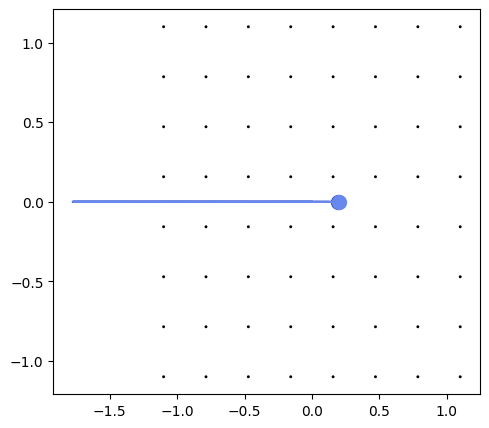

In [38]:
fig, ax = plt.subplots(figsize=(5.5, 5))
norm = colors.Normalize(vmin=-3.5, vmax=3.5)
cmap = rvb

# plot vector field
ax.quiver(
    flip_horizontally * x/xrange, 
    flip_vertically * y/xrange, 
    flip_horizontally * u/xrange, 
    flip_vertically * v/xrange, 
    angles='xy', 
    color='black', 
    scale_units='xy', 
    scale=10, 
    zorder=150
)

# plot trial-averaged trajectories
for i in range(len(evidences)):
    ax.plot(
        flip_horizontally * avg_trajectories[i][:time, 0]/xrange, 
        flip_vertically * avg_trajectories[i][:time, 1]/xrange, 
        '-', color=cmap(norm(evidences[i])), zorder=1100
    )
    ax.plot(
        [flip_horizontally * avg_trajectories[i][time, 0]/xrange], 
        [flip_vertically * avg_trajectories[i][time, 1]/xrange], 
        'o', markersize=10, color=cmap(norm(evidences[i])), zorder=1100
    )

# plot sample zone
z_pc__ = np.reshape(z_pc_[:,:time,:], (-1, 2))
counts,xbins,ybins = np.histogram2d(
    flip_horizontally * z_pc__[:,0] / xrange, 
    flip_vertically * z_pc__[:,1] / xrange,
    bins=30
)
cs = ax.contour(
    counts.transpose(),
    extent=[xbins[0],xbins[-1],ybins[0],ybins[-1]],
    linewidths=1, 
    linestyles = "dashed", 
    cmap = 'gray', 
    levels = [50,10000], 
    zorder=1000)

# axes labels
ax.set_ylabel("PC 2", fontsize=20)
ax.set_xlabel("PC 1", fontsize=20)
ax.set_xticks([-1, 0, 1])
ax.set_yticks([-1, 0, 1])
ax.set_xlim([-1.1, 1.1])
ax.set_ylim([-1.1, 1.1])
ax.tick_params(axis='both', which='major', labelsize=20)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.tight_layout()